# Cap util

2026-01-12 23:25:28.208868: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-12 23:25:28.227339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768260328.248836 2590138 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768260328.255269 2590138 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-12 23:25:28.277614: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

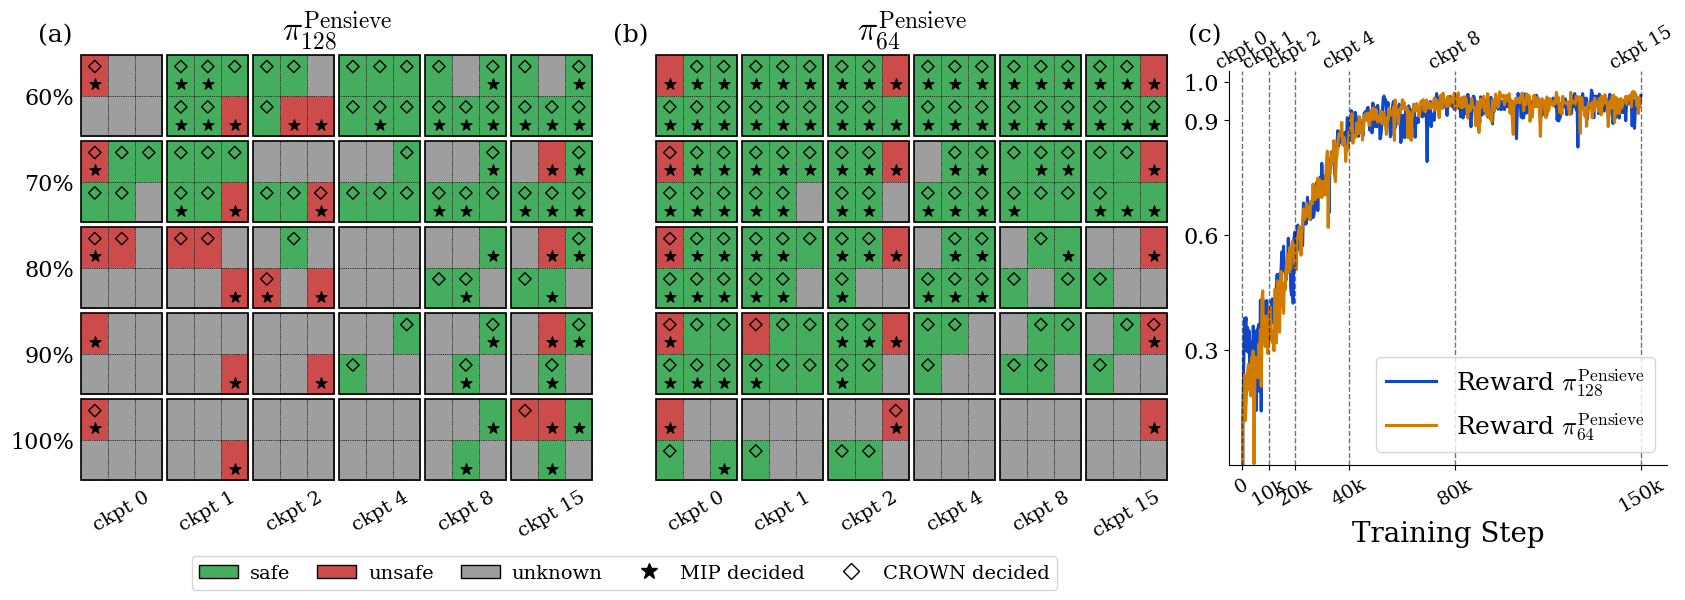

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from tensorboard.backend.event_processing import event_accumulator


def read_event_file(event_file: str):
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={
            event_accumulator.SCALARS: 0,
            event_accumulator.HISTOGRAMS: 0,
            event_accumulator.TENSORS: 0,
        },
    )
    ea.Reload()

    scalars = {}
    for tag in ea.Tags().get("scalars", []):
        events = ea.Scalars(tag)
        scalars[tag] = ([e.step for e in events], [e.value for e in events])
    return scalars


# -------------------- LaTeX-like font (no external LaTeX) --------------------
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 16,
})

# -------------------- Colors --------------------
STATUS_COLOR = {
    "safe": "#45AE5E",
    "unsafe": "#CC4B4B",
    "unknown": "#9E9E9E",
}
REWARD_COLOR_H128 = "#0f47ca"  # navy
REWARD_COLOR_H64  = "#d17c00"  # orange-ish (distinct)

# -------------------- Utilities --------------------
def aggregate(a: str, b: str) -> str:
    # Priority: unsafe > safe > unknown
    if a == "unsafe" or b == "unsafe":
        return "unsafe"
    if a == "safe" or b == "safe":
        return "safe"
    return "unknown"

def kfmt(x, _):
    if abs(x) < 1e-9:
        return "0"
    sign = "-" if x < 0 else ""
    x = abs(x)
    return f"{sign}{int(round(x/1000))}k" if x >= 1000 else f"{sign}{int(x)}"

def draw_table(ax, results_mip, results_crown):
    # aggregate fill + marker masks
    results_agg = {
        m: {
            p: [aggregate(results_mip[m][p][k], results_crown[m][p][k]) for k in range(6)]
            for p in results_mip[m]
        }
        for m in results_mip
    }
    decided_mip = {m: {p: [s != "unknown" for s in results_mip[m][p]] for p in results_mip[m]} for m in results_mip}
    decided_crown = {m: {p: [s != "unknown" for s in results_crown[m][p]] for p in results_crown[m]} for m in results_crown}

    models = list(results_agg.keys())
    percentages = list(next(iter(results_agg.values())).keys())
    n_models, n_perc = len(models), len(percentages)

    STAR_SIZE = 70     # MIP
    DIAMOND_SIZE = 40  # CROWN
    MARKER_EDGE_W = 1.0

    # -------------------- NEW: gap between big cells --------------------
    CELL_GAP = 0.06          # try 0.04–0.10 (in cell units)
    PAD = CELL_GAP / 2.0
    INNER = 1.0 - CELL_GAP   # inner big-cell width/height

    for ip, pct in enumerate(percentages):
        for im, model in enumerate(models):
            vals = results_agg[model][pct]
            x0, y0 = im, ip

            # inner big cell origin (shrunken to create whitespace gap)
            bx = x0 + PAD
            by = y0 + PAD

            for k, status in enumerate(vals):
                r, c = k // 3, k % 3

                # sub-cell geometry inside INNER x INNER region
                sx = bx + (c / 3.0) * INNER
                sy = by + (r / 2.0) * INNER
                sw = (INNER / 3.0)
                sh = (INNER / 2.0)

                # sub-cell fill
                ax.add_patch(Rectangle(
                    (sx, sy), sw, sh,
                    facecolor=STATUS_COLOR[status],
                    edgecolor="black",
                    linewidth=0.6,
                    linestyle=":",
                ))

                # marker positions (still centered in each sub-cell)
                cx = sx + sw * 0.5
                cy_upper = sy + sh * 0.72  # MIP star
                cy_lower = sy + sh * 0.28  # CROWN diamond

                if decided_mip[model][pct][k]:
                    ax.scatter([cx], [cy_upper], marker="*", s=STAR_SIZE,
                               color="black", linewidths=0.8, zorder=5)

                if decided_crown[model][pct][k]:
                    ax.scatter([cx], [cy_lower], marker="D", s=DIAMOND_SIZE,
                               facecolors="none", edgecolors="black",
                               linewidths=MARKER_EDGE_W, zorder=5)

            # outer big cell border (also inside the shrunken area)
            ax.add_patch(Rectangle(
                (bx, by), INNER, INNER,
                fill=False, edgecolor="black", linewidth=1.2
            ))

    ax.set_xlim(0, n_models)
    ax.set_ylim(0, n_perc)
    ax.set_xticks(np.arange(n_models) + 0.5)
    ax.set_xticklabels(models, rotation=30)
    ax.set_yticks(np.arange(n_perc) + 0.5)
    ax.set_yticklabels(percentages)
    ax.set_aspect("equal")
    ax.tick_params(length=0)
    ax.set_frame_on(False)
    ax.invert_yaxis()

    return models, percentages


# ============================================================
# (1) DATASET A: h128  (table + reward)
# ============================================================
event_file_h128 = "/home/mzi/sys-rl-verif/applications/pensieve/pensieve_lib/pretrain/seed_41/events.out.tfevents.1763565931.mec-001.726289.0"
scalars_h128 = read_event_file(event_file_h128)

results_mip_h128 = {
    "ckpt 0": {"60%": ["unsafe","unknown","unknown","unknown","unknown","unknown"],
                "70%": ["unsafe","unknown","unknown","unknown","unknown","unknown"],
                "80%": ["unsafe","unknown","unknown","unknown","unknown","unknown"],
                "90%": ["unsafe","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unsafe","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 1": {"60%": ["safe","safe","unknown","safe","safe","unsafe"],
                "70%": ["unknown","unknown","unknown","safe","unknown","unsafe"],
                "80%": ["unknown","unknown","unknown","unknown","unknown","unsafe"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unsafe"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unsafe"],},
    "ckpt 2": {"60%": ["unknown","unknown","unknown","unknown","unsafe","unsafe"],
                "70%": ["unknown","unknown","unknown","unknown","unknown","unsafe"],
                "80%": ["unknown","unknown","unknown","unsafe","unknown","unsafe"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unsafe"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 4": {"60%": ["unknown","unknown","unknown","unknown","safe","unknown"],
                "70%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "80%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 8": {"60%": ["unknown","unknown","safe","safe","safe","safe"],
                "70%": ["unknown","unknown","safe","safe","safe","unknown"],
                "80%": ["unknown","unknown","safe","unknown","safe","unknown"],
                "90%": ["unknown","unknown","safe","unknown","safe","unknown"],
                "100%":["unknown","unknown","safe","unknown","safe","unknown"],},
    "ckpt 15": {"60%": ["unknown","unknown","safe","safe","safe","safe"],
                "70%": ["unknown","unsafe","safe","safe","safe","safe"],
                "80%": ["unknown","unsafe","safe","unknown","safe","unknown"],
                "90%": ["unknown","unsafe","safe","unknown","safe","unknown"],
                "100%":["unknown","unsafe","safe","unknown","safe","unknown"],},
}

results_crown_h128 = {
    "ckpt 0": {"60%": ["unsafe","unknown","unknown","unknown","unknown","unknown"],
                "70%": ["safe","safe","safe","safe","safe","unknown"],
                "80%": ["unsafe","unsafe","unknown","unknown","unknown","unknown"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unsafe","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 1": {"60%": ["safe","safe","safe","safe","safe","unknown"],
                "70%": ["safe","safe","safe","safe","safe","unknown"],
                "80%": ["unsafe","unsafe","unknown","unknown","unknown","unknown"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 2": {"60%": ["safe","safe","unknown","safe","unknown","unknown"],
                "70%": ["unknown","unknown","unknown","safe","safe","safe"],
                "80%": ["unknown","safe","unknown","safe","unknown","unknown"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 4": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["unknown","unknown","safe","safe","safe","safe"],
                "80%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "90%": ["unknown","unknown","safe","safe","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 8": {"60%": ["safe","unknown","safe","safe","safe","safe"],
                "70%": ["unknown","unknown","safe","safe","safe","safe"],
                "80%": ["unknown","unknown","unknown","safe","safe","unknown"],
                "90%": ["unknown","unknown","safe","unknown","safe","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 15":{"60%": ["safe","unknown","safe","safe","safe","safe"],
                "70%": ["unknown","unknown","safe","safe","safe","safe"],
                "80%": ["unknown","unknown","safe","safe","unknown","unknown"],
                "90%": ["unknown","unknown","safe","unknown","safe","unknown"],
                "100%":["unsafe","unknown","unknown","unknown","unknown","unknown"],},
}

# ============================================================
# (2) DATASET B: h64  (table + reward)
# ============================================================
event_file_h64 = "/home/mzi/sys-rl-verif/applications/pensieve/pensieve_lib/pretrain/h64_seed_41/events.out.tfevents.1765575009.mec-001.3686933.0"
scalars_h64 = read_event_file(event_file_h64)

results_mip_h64 = {
    "ckpt 0": {"60%": ["unsafe","safe","safe","safe","safe","safe"],
                "70%": ["unsafe","safe","safe","safe","safe","safe"],
                "80%": ["unsafe","safe","safe","safe","safe","safe"],
                "90%": ["unsafe","unknown","unknown","safe","safe","safe"],
                "100%":["unsafe","unknown","unknown","unknown","unknown","safe"],},
    "ckpt 1": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["safe","safe","safe","safe","safe","unknown"],
                "80%": ["safe","safe","unknown","safe","safe","unknown"],
                "90%": ["unknown","unknown","unknown","safe","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 2": {"60%": ["safe","safe","unsafe","safe","safe","safe"],
                "70%": ["safe","safe","unsafe","safe","safe","unknown"],
                "80%": ["safe","safe","unsafe","safe","unknown","unknown"],
                "90%": ["safe","safe","unsafe","safe","unknown","unknown"],
                "100%":["unknown","unknown","unsafe","unknown","unknown","unknown"],},
    "ckpt 4": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["unknown","safe","safe","safe","safe","safe"],
                "80%": ["unknown","safe","safe","safe","safe","safe"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 8": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["unknown","safe","safe","safe","unknown","unknown"],
                "80%": ["unknown","unknown","safe","unknown","unknown","unknown"],
                "90%": ["unknown","unknown","unknown","unknown","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 15":{"60%": ["safe","safe","unsafe","safe","safe","safe"],
                "70%": ["unknown","unknown","unsafe","safe","safe","safe"],
                "80%": ["unknown","unknown","unsafe","unknown","unknown","unknown"],
                "90%": ["unknown","unknown","unsafe","unknown","unknown","unknown"],
                "100%":["unknown","unknown","unsafe","unknown","unknown","unknown"],},
}

results_crown_h64 = {
    "ckpt 0": {"60%": ["unknown","safe","safe","safe","safe","safe"],
                "70%": ["unsafe","safe","safe","safe","safe","safe"],
                "80%": ["unsafe","safe","safe","safe","safe","safe"],
                "90%": ["unsafe","safe","safe","safe","safe","safe"],
                "100%":["unknown","unknown","unknown","safe","unknown","unknown"],},
    "ckpt 1": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["safe","safe","safe","safe","safe","unknown"],
                "80%": ["safe","safe","safe","safe","safe","unknown"],
                "90%": ["unsafe","safe","safe","safe","safe","safe"],
                "100%":["unknown","unknown","unknown","safe","unknown","unknown"],},
    "ckpt 2": {"60%": ["safe","safe","unknown","safe","safe","unknown"],
                "70%": ["safe","safe","unknown","safe","safe","unknown"],
                "80%": ["safe","safe","unknown","safe","unknown","unknown"],
                "90%": ["safe","safe","unknown","safe","safe","unknown"],
                "100%":["unknown","unknown","safe","safe","safe","unknown"],},
    "ckpt 4": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["unknown","safe","safe","safe","safe","safe"],
                "80%": ["unknown","safe","safe","safe","safe","safe"],
                "90%": ["safe","safe","unknown","safe","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 8": {"60%": ["safe","safe","safe","safe","safe","safe"],
                "70%": ["safe","safe","safe","safe","safe","safe"],
                "80%": ["unknown","safe","unknown","safe","unknown","safe"],
                "90%": ["unknown","safe","safe","safe","safe","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
    "ckpt 15":{"60%": ["safe","safe","unknown","safe","safe","safe"],
                "70%": ["safe","safe","unknown","safe","unknown","unknown"],
                "80%": ["unknown","unknown","unknown","safe","unknown","unknown"],
                "90%": ["unknown","safe","safe","safe","unknown","unknown"],
                "100%":["unknown","unknown","unknown","unknown","unknown","unknown"],},
}

# -------------------- Reward snapshots (same x positions for both curves) --------------------
MODEL_SNAPSHOTS = {
    "ckpt 0": 0,
    "ckpt 1": 10200,
    "ckpt 2": 20100,
    "ckpt 4": 40200,
    "ckpt 8": 80100,
    "ckpt 15": 150000,
}

# ============================================================
# ONE FIGURE: [Table(h128)] [Table(h64)] [Reward(both)]
# ============================================================
fig = plt.figure(figsize=(20.5, 6.4))
# make reward panel smaller: third width ratio < 1
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1.0, 1.0, 0.85], wspace=0.12)

# (a) Table: h128
ax_t1 = fig.add_subplot(gs[0, 0])
draw_table(ax_t1, results_mip_h128, results_crown_h128)
ax_t1.set_title(r"$\pi^{\text{Pensieve}}_{128}$", pad=8, fontsize=24)

# (b) Table: h64
ax_t2 = fig.add_subplot(gs[0, 1])
draw_table(ax_t2, results_mip_h64, results_crown_h64)
ax_t2.set_title(r"$\pi^{\text{Pensieve}}_{64}$", pad=8, fontsize=24)
ax_t2.set_ylabel("")  # avoid repeating y-label
ax_t2.set_yticklabels([])

# Shared legend under the TWO tables (centered between them)
legend_handles = [
    Patch(facecolor=STATUS_COLOR["safe"], edgecolor="black", label="safe"),
    Patch(facecolor=STATUS_COLOR["unsafe"], edgecolor="black", label="unsafe"),
    Patch(facecolor=STATUS_COLOR["unknown"], edgecolor="black", label="unknown"),
    Line2D([0], [0], marker="*", linestyle="None",
           color="black", markersize=12, label="MIP decided"),
    Line2D([0], [0], marker="D", linestyle="None",
           markerfacecolor="none", markeredgecolor="black",
           markersize=8, label="CROWN decided"),
]
pos1, pos2 = ax_t1.get_position(), ax_t2.get_position()
x_center_tables = (pos1.x0 + pos2.x1) / 2.0
y_under_tables = min(pos1.y0, pos2.y0) - 0.1

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(x_center_tables, y_under_tables),
    ncol=5,
    frameon=True,
    fontsize=14,
    handletextpad=0.6,
    columnspacing=1.4,
)

# (c) Reward: both curves
ax_r = fig.add_subplot(gs[0, 2])
ax_r.set_xlim(-5000, 160000)
ax_r.set_ylim(0.0, 1.03)

# plot both reward curves
ax_r.plot(scalars_h128["Reward"][0], scalars_h128["Reward"][1],
          color=REWARD_COLOR_H128, linewidth=2.2, label=r"Reward $\pi^{\text{Pensieve}}_{128}$")
ax_r.plot(scalars_h64["Reward"][0], scalars_h64["Reward"][1],
          color=REWARD_COLOR_H64, linewidth=2.2, label=r"Reward $\pi^{\text{Pensieve}}_{64}$")

# snapshot markers (shared)
for name, step in MODEL_SNAPSHOTS.items():
    ax_r.axvline(step, linestyle="--", linewidth=1.0, alpha=0.55, color="black")
    ax_r.text(step, 1.025, name, rotation=30, ha="center", va="bottom", fontsize=13)

ax_r.set_xlabel("Training Step")
ax_r.set_ylabel("")
ax_r.grid(False)
ax_r.spines["top"].set_visible(False)
ax_r.spines["right"].set_visible(False)

ax_r.set_xticks(sorted(MODEL_SNAPSHOTS.values()))
ax_r.xaxis.set_major_formatter(FuncFormatter(kfmt))
for lbl in ax_r.get_xticklabels():
    lbl.set_rotation(30)

ax_r.set_yticks([0.3, 0.6, 0.9, 1.0])
ax_r.legend(frameon=True, fontsize=18, loc="lower right")

# shrink reward panel height a bit (like your earlier style)
fig.canvas.draw()
pos_r = ax_r.get_position()
new_height = pos_r.height * 0.80
new_y0 = pos_r.y0 + 0.5 * (pos_r.height - new_height)
ax_r.set_position([pos_r.x0, new_y0, pos_r.width, new_height])

# Panel labels (a)(b)(c)
fig.canvas.draw()
p1, p2, p3 = ax_t1.get_position(), ax_t2.get_position(), ax_r.get_position()
y_label = max(p1.y1, p2.y1, p3.y1) + 0.01
x_offset = 0.020
fig.text(p1.x0 - x_offset, y_label, "(a)", ha="left", va="bottom", fontsize=18)
fig.text(p2.x0 - x_offset, y_label, "(b)", ha="left", va="bottom", fontsize=18)
fig.text(p3.x0 - x_offset, y_label, "(c)", ha="left", va="bottom", fontsize=18)

# fig.subplots_adjust(left=0.035, right=0.995, top=0.92, bottom=0.18)

plt.savefig("pensieve_caputil_merged.pdf", format="pdf", bbox_inches="tight")
plt.show()


## the other two

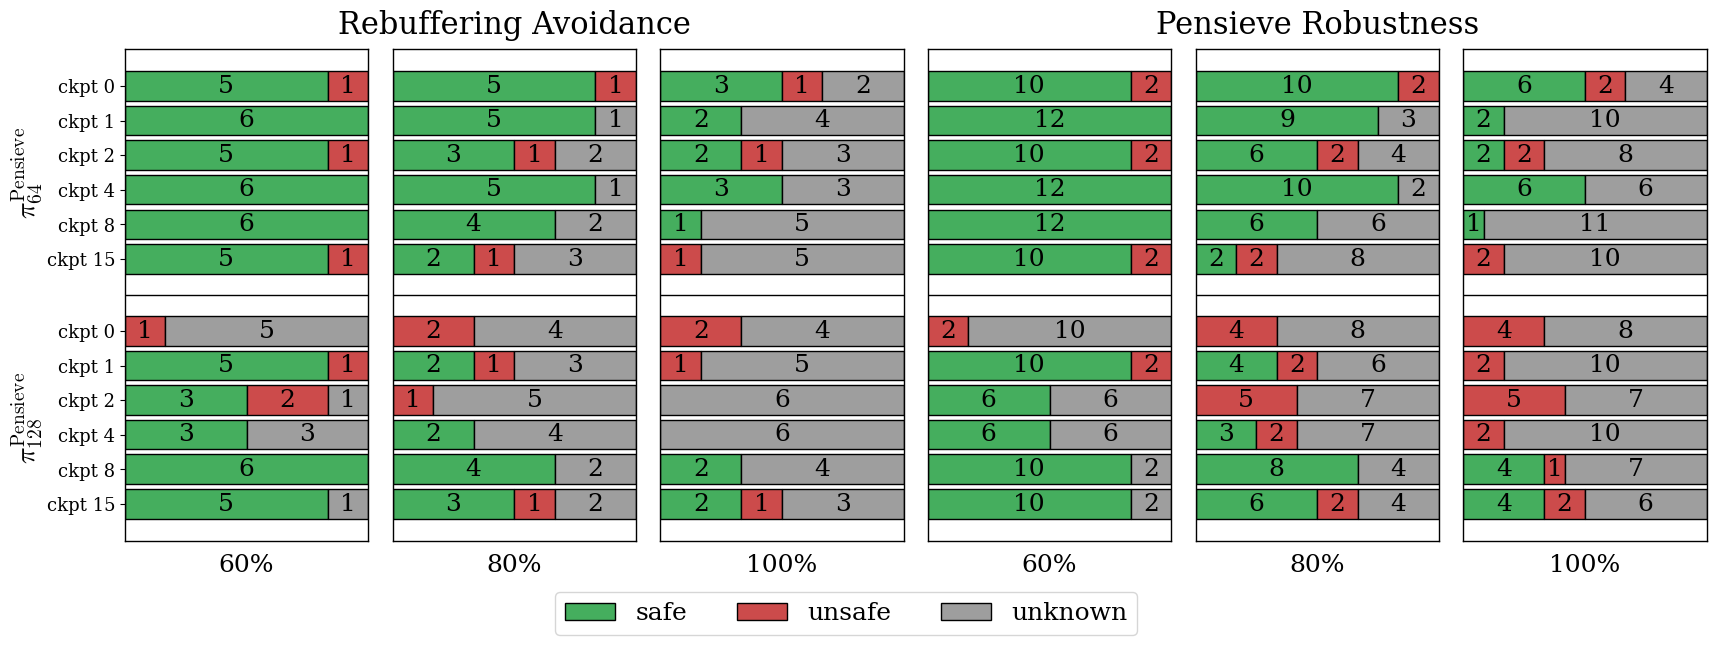

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import re

# -------------------- Styling (no external LaTeX; use mathtext) --------------------
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 13,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

STATUS_COLOR = {
    "safe":   "#45AE5E",
    "unsafe": "#CC4B4B",
    "unknown":"#9E9E9E",
}

# -------------------- Make bars thicker + figure taller --------------------
BAR_THICKNESS = 1.45     # was effectively 0.9 inside draw_stacked_barh
ROW_STEP      = 1.7     # increase spacing to avoid overlap with thicker bars
BLOCK_GAP     = 1.85     # separation between pi_64 and pi_128 blocks
FIGSIZE       = (18.5, 8.2)  # taller than before (was 6.2)

# -------------------- Your results --------------------
rebuffering_128 = {
    "ckpt 0": {"60":  ["unsafe","unknown","unknown","unknown","unknown","unknown"],
                "80":  ["unsafe","unsafe","unknown","unknown","unknown","unknown"],
                "100": ["unsafe","unsafe","unknown","unknown","unknown","unknown"]},
    "ckpt 1": {"60":  ["safe","safe","safe","safe","safe","unsafe"],
                "80":  ["unknown","safe","unknown","safe","unknown","unsafe"],
                "100": ["unknown","unknown","unknown","unknown","unknown","unsafe"]},
    "ckpt 2": {"60":  ["safe","safe","unknown","safe","unsafe","unsafe"],
                "80":  ["unknown","unknown","unknown","unknown","unsafe","unknown"],
                "100": ["unknown","unknown","unknown","unknown","unknown","unknown"]},
    "ckpt 4": {"60":  ["unknown","unknown","unknown","safe","safe","safe"],
                "80":  ["unknown","unknown","unknown","safe","safe","unknown"],
                "100": ["unknown","unknown","unknown","unknown","unknown","unknown"]},
    "ckpt 8": {"60":  ["safe","safe","safe","safe","safe","safe"],
                "80":  ["unknown","unknown","safe","safe","safe","safe"],
                "100": ["unknown","unknown","safe","unknown","safe","unknown"]},
    "ckpt 15":{"60":  ["safe","unknown","safe","safe","safe","safe"],
                "80":  ["unknown","unsafe","safe","safe","safe","unknown"],
                "100": ["unknown","unsafe","safe","unknown","safe","unknown"]},
}

rebuffering_64 = {
    "ckpt 0": {"60":  ["unsafe","safe","safe","safe","safe","safe"],
                "80":  ["unsafe","safe","safe","safe","safe","safe"],
                "100": ["unsafe","unknown","unknown","safe","safe","safe"]},
    "ckpt 1": {"60":  ["safe","safe","safe","safe","safe","safe"],
                "80":  ["safe","safe","safe","safe","safe","unknown"],
                "100": ["unknown","unknown","unknown","safe","safe","unknown"]},
    "ckpt 2": {"60":  ["safe","safe","unsafe","safe","safe","safe"],
                "80":  ["safe","safe","unsafe","safe","unknown","unknown"],
                "100": ["safe","safe","unsafe","unknown","unknown","unknown"]},
    "ckpt 4": {"60":  ["safe","safe","safe","safe","safe","safe"],
                "80":  ["unknown","safe","safe","safe","safe","safe"],
                "100": ["unknown","unknown","safe","safe","safe","unknown"]},
    "ckpt 8": {"60":  ["safe","safe","safe","safe","safe","safe"],
                "80":  ["unknown","safe","safe","safe","unknown","safe"],
                "100": ["unknown","safe","unknown","unknown","unknown","unknown"]},
    "ckpt 15":{"60":  ["safe","safe","unsafe","safe","safe","safe"],
                "80":  ["safe","unknown","unsafe","safe","unknown","unknown"],
                "100": ["unknown","unknown","unsafe","unknown","unknown","unknown"]},
}

robustness_128 = {
    "ckpt 0": {
        "60":  ["unsafe","unknown","unknown","unknown","unknown","unknown","unsafe","unknown","unknown","unknown","unknown","unknown"],
        "80":  ["unsafe","unsafe","unknown","unknown","unknown","unknown","unsafe","unsafe","unknown","unknown","unknown","unknown"],
        "100": ["unsafe","unsafe","unknown","unknown","unknown","unknown","unsafe","unsafe","unknown","unknown","unknown","unknown"],
    },
    "ckpt 1": {
        "60":  ["safe","safe","safe","safe","safe","unsafe","safe","safe","safe","safe","safe","unsafe"],
        "80":  ["unknown","safe","safe","unknown","unknown","unsafe","unknown","safe","unknown","safe","unknown","unsafe"],
        "100": ["unknown","unknown","unknown","unknown","unknown","unsafe","unknown","unknown","unknown","unknown","unknown","unsafe"],
    },
    "ckpt 2": {
        "60":  ["safe","safe","safe","unknown","unknown","unknown","safe","safe","unknown","safe","unknown","unknown"],
        "80":  ["unknown","unknown","unsafe","unknown","unsafe","unknown","unknown","unknown","unknown","unsafe","unsafe","unsafe"],
        "100": ["unknown","unknown","unsafe","unknown","unsafe","unknown","unknown","unknown","unknown","unsafe","unsafe","unsafe"],
    },
    "ckpt 4": {
        "60":  ["unknown","unknown","safe","unknown","safe","safe","unknown","unknown","unknown","safe","safe","safe"],
        "80":  ["unsafe","unknown","safe","unknown","safe","unknown","unsafe","unknown","unknown","unknown","safe","unknown"],
        "100": ["unsafe","unknown","unknown","unknown","unknown","unknown","unsafe","unknown","unknown","unknown","unknown","unknown"],
    },
    "ckpt 8": {
        "60":  ["unknown","safe","safe","safe","safe","safe","unknown","safe","safe","safe","safe","safe"],
        "80":  ["unknown","unknown","safe","safe","safe","safe","unknown","unknown","safe","safe","safe","safe"],
        "100": ["unknown","unsafe","unknown","safe","safe","unknown","unknown","unknown","safe","unknown","safe","unknown"],
    },
    "ckpt 15": {
        "60":  ["safe","unknown","safe","safe","safe","safe","safe","unknown","safe","safe","safe","safe"],
        "80":  ["unknown","unsafe","safe","safe","safe","unknown","unknown","unsafe","safe","safe","safe","unknown"],
        "100": ["unknown","unsafe","unknown","safe","safe","unknown","unknown","unsafe","safe","unknown","safe","unknown"],
    },
}

robustness_64 = {
    "ckpt 0": {
        "60":  ["unsafe","safe","safe","safe","safe","safe","unsafe","safe","safe","safe","safe","safe"],
        "80":  ["unsafe","safe","safe","safe","safe","safe","unsafe","safe","safe","safe","safe","safe"],
        "100": ["unsafe","unknown","safe","unknown","safe","safe","unsafe","unknown","unknown","safe","safe","safe"],
    },
    "ckpt 1": {
        "60":  ["safe","safe","safe","safe","safe","safe","safe","safe","safe","safe","safe","safe"],
        "80":  ["safe","safe","safe","safe","safe","unknown","unknown","safe","safe","safe","safe","unknown"],
        "100": ["unknown","unknown","safe","unknown","unknown","unknown","unknown","unknown","unknown","safe","unknown","unknown"],
    },
    "ckpt 2": {
        "60":  ["safe","safe","safe","unsafe","safe","safe","safe","safe","unsafe","safe","safe","safe"],
        "80":  ["safe","safe","safe","unsafe","unknown","unknown","safe","safe","unsafe","safe","unknown","unknown"],
        "100": ["safe","unknown","unknown","unsafe","unknown","unknown","safe","unknown","unsafe","unknown","unknown","unknown"],
    },
    "ckpt 4": {
        "60":  ["safe","safe","safe","safe","safe","safe","safe","safe","safe","safe","safe","safe"],
        "80":  ["unknown","safe","safe","safe","safe","safe","unknown","safe","safe","safe","safe","safe"],
        "100": ["unknown","unknown","safe","safe","safe","unknown","unknown","unknown","safe","safe","safe","unknown"],
    },
    "ckpt 8": {
        "60":  ["safe","safe","safe","safe","safe","safe","safe","safe","safe","safe","safe","safe"],
        "80":  ["unknown","safe","safe","safe","unknown","unknown","unknown","safe","safe","safe","unknown","unknown"],
        "100": ["unknown","unknown","unknown","unknown","unknown","unknown","unknown","unknown","safe","unknown","unknown","unknown"],
    },
    "ckpt 15": {
        "60":  ["safe","safe","safe","unsafe","safe","safe","safe","safe","unsafe","safe","safe","safe"],
        "80":  ["unknown","unknown","safe","unsafe","unknown","unknown","unknown","unknown","unsafe","safe","unknown","unknown"],
        "100": ["unknown","unknown","unknown","unsafe","unknown","unknown","unknown","unknown","unsafe","unknown","unknown","unknown"],
    },
}

# -------------------- Layout + helpers --------------------
PERCENTS = ["60", "80", "100"]

def counts_from_list(status_list):
    c = {k: 0 for k in STATUS_COLOR}
    for s in status_list:
        s = str(s).replace("(", "").replace(")", "")
        if s not in c:
            raise ValueError(f"Unknown status '{s}'. Expected {list(c.keys())}.")
        c[s] += 1
    return c, len(status_list)

def draw_stacked_barh(ax, y, counts, height=0.9, edgecolor="black", lw=1.0):
    left = 0
    for status in ["safe", "unsafe", "unknown"]:
        w = counts[status]
        if w <= 0:
            continue
        ax.barh(
            y=y, width=w, left=left, height=height,
            color=STATUS_COLOR[status], edgecolor=edgecolor, linewidth=lw
        )
        ax.text(
            left + w/2, y, f"{w}",
            ha="center", va="center",
            fontsize=18, color="black"
        )
        left += w

_ckpt_re = re.compile(r"ckpt\s*(\d+)", re.IGNORECASE)

def ckpt_key_to_int(k: str) -> int:
    m = _ckpt_re.search(str(k))
    return int(m.group(1)) if m else 10**9

def all_ckpts_for_property(data_by_group):
    keys = set()
    for grp in ["64", "128"]:
        keys |= set(data_by_group[grp].keys())
    return sorted(keys, key=ckpt_key_to_int)

def infer_list_len(data_by_group, perc):
    for grp in ["64", "128"]:
        for m, percs in data_by_group[grp].items():
            if perc in percs and percs[perc] is not None:
                return len(percs[perc])
    raise ValueError(f"Could not infer list length for perc={perc}%")

def get_status_list(data_by_group, grp, model, perc, default_len):
    if model in data_by_group[grp] and perc in data_by_group[grp][model]:
        return data_by_group[grp][model][perc]
    return ["unknown"] * default_len

def build_rows(ckpt_list):
    rows = []
    y = 0.0

    # pi_64 block
    for m in ckpt_list:
        rows.append({"group": "64", "model": m, "y": y})
        y += ROW_STEP

    y += BLOCK_GAP  # block gap

    # pi_128 block
    for m in ckpt_list:
        rows.append({"group": "128", "model": m, "y": y})
        y += ROW_STEP

    return rows

def max_total_for_property(data_by_group, ckpt_list):
    mx = 0
    for p in PERCENTS:
        default_len = infer_list_len(data_by_group, p)
        for grp in ["64", "128"]:
            for m in ckpt_list:
                lst = get_status_list(data_by_group, grp, m, p, default_len)
                _, total = counts_from_list(lst)
                mx = max(mx, total)
    return mx

# -------------------- Figure: 2 properties × 3 coverages = 6 columns --------------------
fig, axes = plt.subplots(
    nrows=1, ncols=6, figsize=FIGSIZE,
    gridspec_kw={"wspace": 0.10}
)

properties = [
    ("Rebuffering Avoidance", {"64": rebuffering_64, "128": rebuffering_128}),
    ("Robustness",            {"64": robustness_64,  "128": robustness_128}),
]

rows_by_prop = []
sep_y_by_prop = []

for prop_idx, (prop_name, data_by_group) in enumerate(properties):
    ckpt_list = all_ckpts_for_property(data_by_group)
    rows = build_rows(ckpt_list)
    rows_by_prop.append(rows)

    n = len(ckpt_list)
    sep_y = (rows[n-1]["y"] + rows[n]["y"]) / 2.0
    sep_y_by_prop.append(sep_y)

    y_vals = [r["y"] for r in rows]
    y_labels = [r["model"] for r in rows]

    mx_total = max_total_for_property(data_by_group, ckpt_list)

    for j, perc in enumerate(PERCENTS):
        ax = axes[prop_idx * 3 + j]
        default_len = infer_list_len(data_by_group, perc)

        for r in rows:
            grp = r["group"]
            model = r["model"]
            status_list = get_status_list(data_by_group, grp, model, perc, default_len)
            c, _ = counts_from_list(status_list)
            draw_stacked_barh(ax, r["y"], c, height=BAR_THICKNESS)  # <-- thicker bars

        ax.set_xticks([])
        ax.set_xlabel("")
        ax.text(
            0.5, -0.025, f"{perc}%",
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=18,
            clip_on=False
        )

        ax.set_xlim(0, mx_total)

        ax.set_yticks(y_vals)
        ax.invert_yaxis()
        if prop_idx == 0 and j == 0:
            ax.set_yticklabels(y_labels)
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)

        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            spine.set_color("black")

for prop_idx in [0, 1]:
    sep_y = sep_y_by_prop[prop_idx]
    for j in range(3):
        ax = axes[prop_idx * 3 + j]
        ax.axhline(sep_y, color="black", linewidth=1.0)

plt.subplots_adjust(left=0.14, right=0.995, top=0.84, bottom=0.24)

fig.canvas.draw()

def xcenter_of_bars_in_figcoords(ax):
    x0, x1 = ax.get_xlim()
    x_mid = 0.5 * (x0 + x1)
    y0, y1 = ax.get_ylim()
    y_mid = 0.5 * (y0 + y1)
    x_disp, y_disp = ax.transData.transform((x_mid, y_mid))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_disp, y_disp))
    return x_fig

x_center_reb = xcenter_of_bars_in_figcoords(axes[1])
x_center_rob = xcenter_of_bars_in_figcoords(axes[4])

y_top = max(ax.get_position().y1 for ax in axes) + 0.01
fig.text(x_center_reb, y_top, "Rebuffering Avoidance",
         ha="center", va="bottom", fontsize=22)
fig.text(x_center_rob, y_top, "Pensieve Robustness",
         ha="center", va="bottom", fontsize=22)

def data_y_to_ax_frac(ax, y_data):
    return ax.transAxes.inverted().transform(ax.transData.transform((0, y_data)))[1]

ax0 = axes[0]

rows0 = rows_by_prop[0]
ckpt_list0 = all_ckpts_for_property(properties[0][1])
n0 = len(ckpt_list0)

mid_64  = (rows0[0]["y"] + rows0[n0-1]["y"]) / 2.0
mid_128 = (rows0[n0]["y"] + rows0[-1]["y"]) / 2.0

y64_frac  = data_y_to_ax_frac(ax0, mid_64)
y128_frac = data_y_to_ax_frac(ax0, mid_128)

ax0.text(
    x=-0.4, y=y64_frac,
    s=r"$\pi_{64}^{\mathrm{Pensieve}}$",
    transform=ax0.transAxes,
    rotation=90,
    ha="center", va="center",
    fontsize=20,
    clip_on=False
)
ax0.text(
    x=-0.4, y=y128_frac,
    s=r"$\pi_{128}^{\mathrm{Pensieve}}$",
    transform=ax0.transAxes,
    rotation=90,
    ha="center", va="center",
    fontsize=20,
    clip_on=False
)

legend_handles = [
    Patch(facecolor=STATUS_COLOR["safe"],   edgecolor="black", label="safe"),
    Patch(facecolor=STATUS_COLOR["unsafe"], edgecolor="black", label="unsafe"),
    Patch(facecolor=STATUS_COLOR["unknown"],edgecolor="black", label="unknown"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           frameon=True, fontsize=18, bbox_to_anchor=(0.53, 0.11))

plt.savefig(
    "penseive_rob_bufavoid.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
